Seasonal Agriculture Performance Analysis

    Major Data Analytics Project

Domin             : Agriculture
Project Theme     : Seasonal Agriculture Performanc
Tools             : Python, Pandas, NumPy, Matplotlib, Seaborn

1. Import Libraries

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

2. Load the Dataset

In [113]:
FILE_NAME = "seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(FILE_NAME)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (4000, 28)


3. Top 5 Rows Analyzed

In [114]:
display(df.head())

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


4. Dataset Shape and Structure Examined

#Data Understanding

In [115]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Rows: 4000
Columns: 28

Column Names:
1. Farm_ID
2. State
3. District
4. Crop
5. Season
6. Farm_Area_Hectares
7. Rainfall_mm
8. Avg_Temperature_C
9. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct


5. Data Types Examined

In [116]:
print("Data Types:")
print(df.dtypes)

Data Types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Prof

In [117]:
print("Basic Information:")
df.info()

Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha               

6. Missing Values Identified and Handled

In [118]:
missing_before = df.isna().sum().sort_values(ascending=False)
missing_table = pd.DataFrame({
    "Missing_Count": missing_before,
    "Missing_Percentage": (missing_before / len(df) * 100).round(2)
})

print("Missing values before treatment:")
display(missing_table[missing_table["Missing_Count"] > 0])

Missing values before treatment:


,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


In [119]:
clean = df.copy()

impute_cols = ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]

for col in impute_cols:
    clean[col] = clean.groupby("Season")[col].transform(
        lambda s: s.fillna(s.median())
    )

print("Missing values after treatment:")
missing_after = clean.isna().sum().sort_values(ascending=False)
display(missing_after[missing_after > 0])

Missing values after treatment:


Series([], dtype: int64)

In [120]:
print("Season Distribution:")
display(df["Season"].value_counts())

Season Distribution:


Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

In [23]:
print("Crop Distribution:")
display(df["Crop"].value_counts())

Crop Distribution:


Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

In [24]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,"4,000.00",NaN,NaN,NaN,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",NaN,NaN,NaN,601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",NaN,NaN,NaN,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",NaN,NaN,NaN,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",NaN,NaN,NaN,7.32,1.12,3.50,6.60,7.30,8.10,11.00


7.  Duplicate Records Identified and Handled

In [29]:
# Checking Duplicate Rows
df_clean = df.copy()
print("Duplicate Rows:", df_clean.duplicated().sum())

Duplicate Rows: 0


In [41]:
missing_columns = [
    "Rainfall_mm",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha"
]
for col in missing_columns:
    df_clean[col] = df_clean.groupby("Season")[col].transform(
        lambda x: x.fillna(x.median())
    )

In [33]:
print("Total Missing Values:", df_clean.isnull().sum().sum())

Total Missing Values: 0


8. Feature Engineering — Profit Margin and ROI

In [81]:
clean["Profit_Margin_pct"] = np.where(
    clean["Revenue_INR"] != 0,
    clean["Profit_INR"] / clean["Revenue_INR"] * 100,
    np.nan
)

clean["ROI_pct"] = np.where(
    clean["Total_Cost_INR"] != 0,
    clean["Profit_INR"] / clean["Total_Cost_INR"] * 100,
    np.nan
)

display(
    clean[
        [
            "Revenue_INR",
            "Total_Cost_INR",
            "Profit_INR",
            "Profit_Margin_pct",
            "ROI_pct"
        ]
    ].head()
)

,Revenue_INR,Total_Cost_INR,Profit_INR,Profit_Margin_pct,ROI_pct
0,30810,42662,-11852,-38.47,-27.78
1,40401,492351,-451950,"-1,118.66",-91.79
2,190466,315210,-124744,-65.49,-39.57
3,200740,296444,-95704,-47.68,-32.28
4,193607,337959,-144352,-74.56,-42.71


9. Statistical Analysis

In [43]:
summary = clean.select_dtypes(include="number").describe().T
display(summary)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"3,960.00",26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [82]:
# Additional statistical measures
stat_table = clean.select_dtypes(include="number").agg(
    ["mean", "median", "std", "min", "max"]
).T

display(stat_table)

,mean,median,std,min,max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.71,581.00,288.43,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.50,26.40,6.70,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


10. Outliers Investigated

Outliers are investigated using the IQR method. They are not automatically deleted because extreme agricultural values may be genuine observations.

In [83]:
numerical_columns = clean.select_dtypes(include="number").columns

outlier_results = []

for col in numerical_columns:
    q1 = clean[col].quantile(0.25)
    q3 = clean[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = (clean[col] < lower_bound) | (clean[col] > upper_bound)

    outlier_results.append({
        "Column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": int(mask.sum()),
        "Outlier_Percentage": mask.mean() * 100
    })

outlier_df = pd.DataFrame(outlier_results).sort_values(
    "Outlier_Count", ascending=False
)

display(outlier_df.head(15))

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,"-148,731.75","216,187.75","364,919.50","-696,111.00","763,567.00",404,10.10
22,Profit_Margin_pct,-60.19,32.89,93.08,-199.81,172.50,362,9.05
14,Production_Tonnes,5.02,24.36,19.34,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,1.66,5.15,3.49,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,1.05,2.83,1.78,-1.62,5.50,302,7.55
23,ROI_pct,-37.58,49.00,86.58,-167.44,178.86,286,7.15
19,Water_Used_m3,"2,268.75","7,829.75","5,561.00","-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"207,517.25","836,874.75","629,357.50","-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,86.20,123.60,37.40,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,6.60,8.10,1.50,4.35,10.35,26,0.65


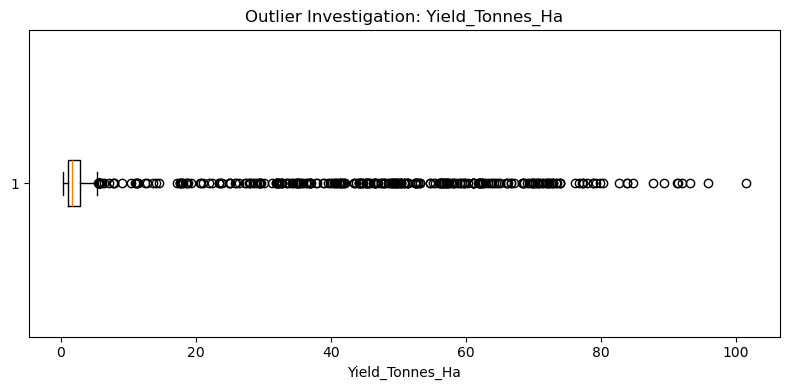

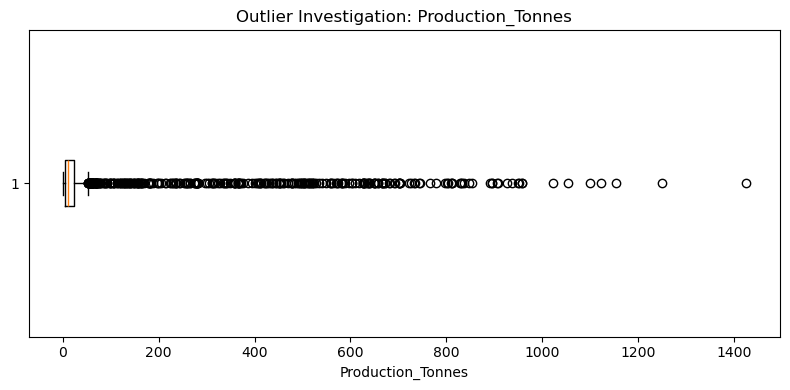

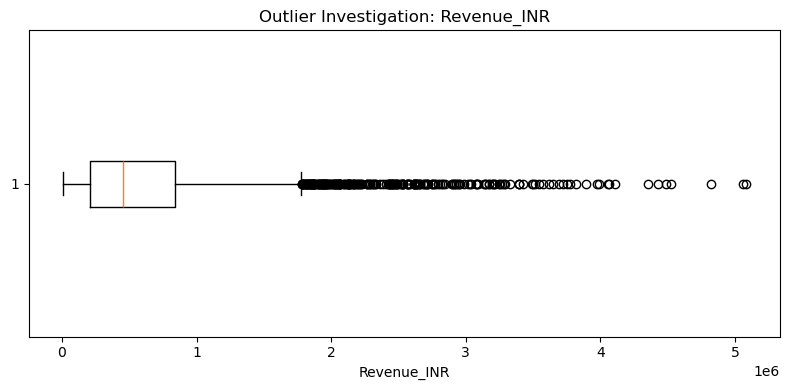

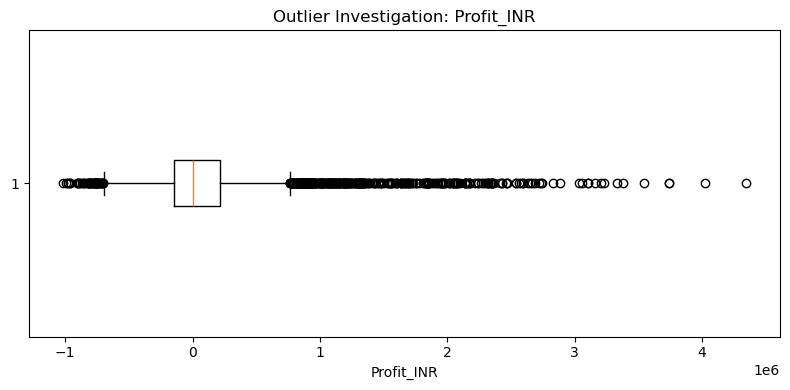

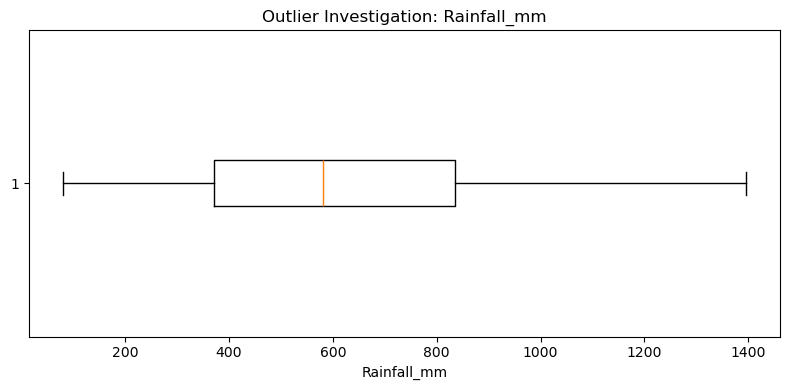

In [84]:
# Boxplots for important agricultural variables
boxplot_cols = [
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Revenue_INR",
    "Profit_INR",
    "Rainfall_mm"
]

for col in boxplot_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(clean[col].dropna(), vert=False)
    plt.title(f"Outlier Investigation: {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

Outlier interpretation
The IQR method identifies unusually low or high observations. These are retained unless there is evidence they are data-entry errors. Retaining legitimate extremes is important because agricultural production, rainfall and profit can naturally vary widely.

11. Univariate Analysis

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

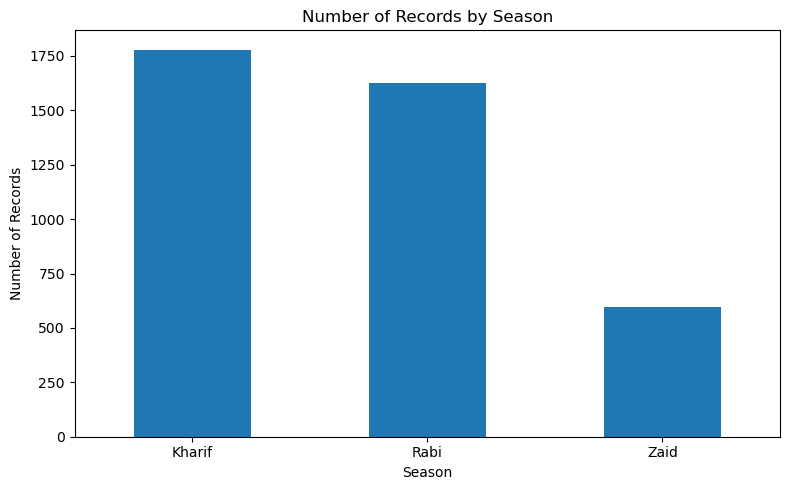

In [86]:
# Season frequency
season_counts = clean["Season"].value_counts()

display(season_counts)

season_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Number of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

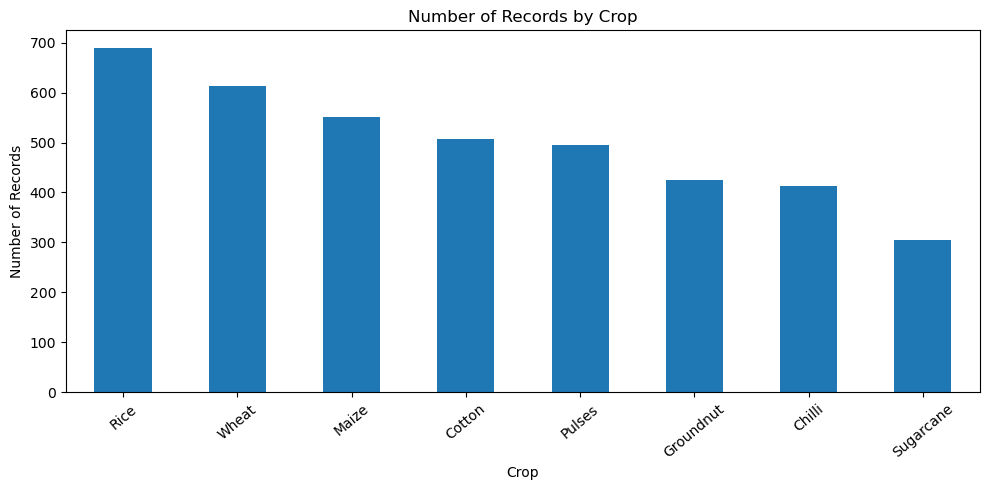

In [87]:
# Crop frequency
crop_counts = clean["Crop"].value_counts()

display(crop_counts)

crop_counts.plot(kind="bar", figsize=(10, 5))
plt.title("Number of Records by Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

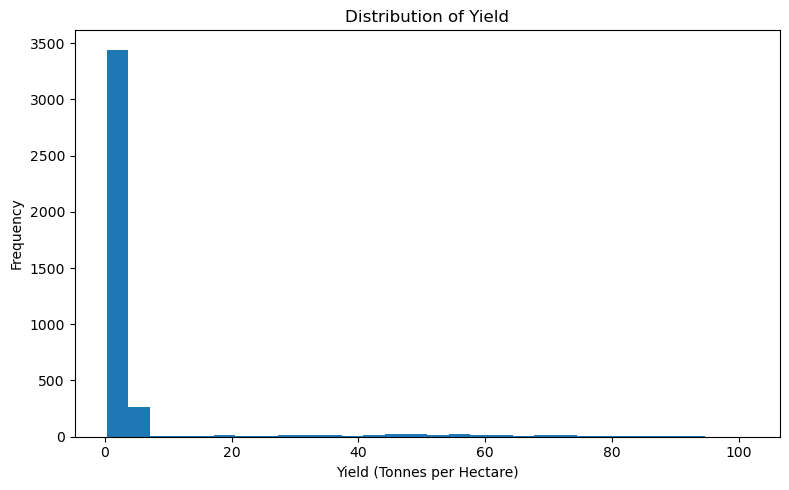

In [88]:
# Yield distribution
plt.figure(figsize=(8, 5))
plt.hist(clean["Yield_Tonnes_Ha"], bins=30)
plt.title("Distribution of Yield")
plt.xlabel("Yield (Tonnes per Hectare)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

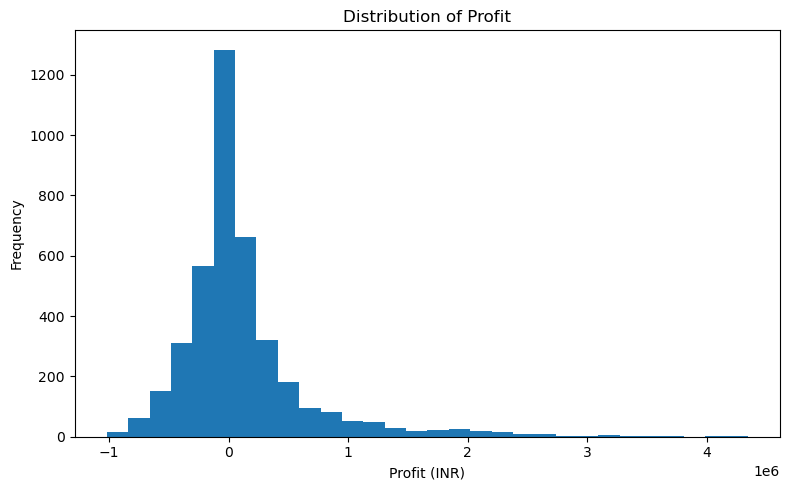

In [89]:
# Profit distribution
plt.figure(figsize=(8, 5))
plt.hist(clean["Profit_INR"], bins=30)
plt.title("Distribution of Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Univariate findings

12. Bivariate Analysis

Bivariate analysis studies the relationship between two variables at a time.

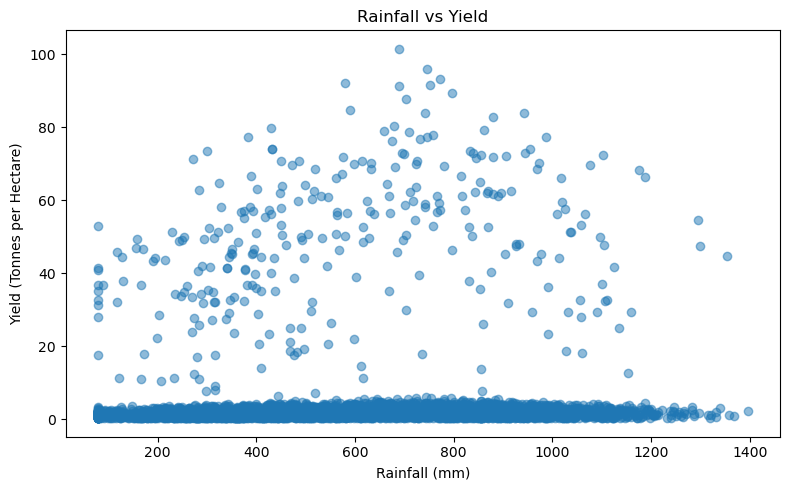

In [91]:
# Rainfall vs Yield
plt.figure(figsize=(8, 5))
plt.scatter(clean["Rainfall_mm"], clean["Yield_Tonnes_Ha"], alpha=0.5)
plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes per Hectare)")
plt.tight_layout()
plt.show()

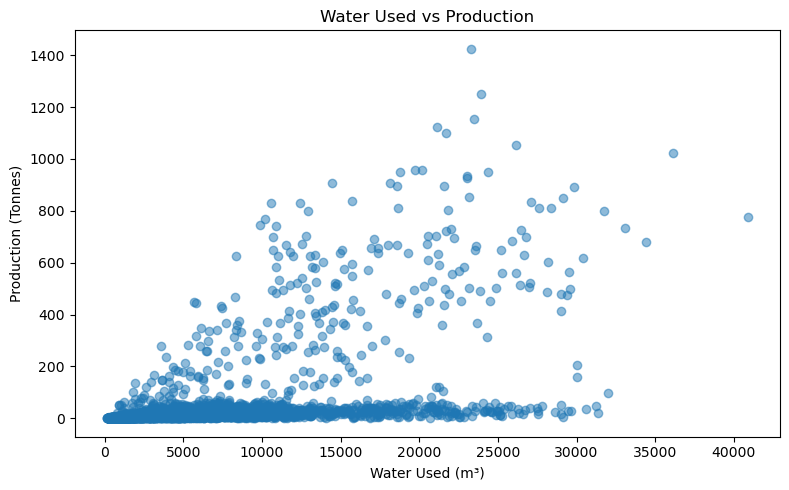

In [92]:
# Water Used vs Production
plt.figure(figsize=(8, 5))
plt.scatter(clean["Water_Used_m3"], clean["Production_Tonnes"], alpha=0.5)
plt.title("Water Used vs Production")
plt.xlabel("Water Used (m³)")
plt.ylabel("Production (Tonnes)")
plt.tight_layout()
plt.show()

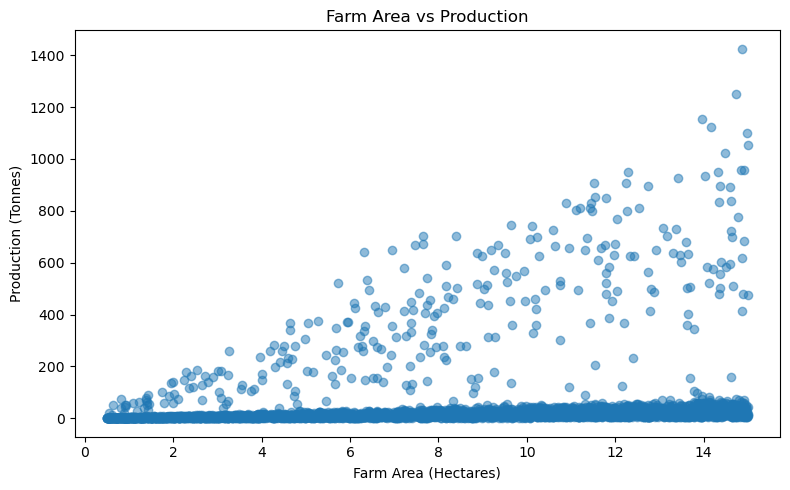

In [93]:
# Farm Area vs Production
plt.figure(figsize=(8, 5))
plt.scatter(clean["Farm_Area_Hectares"], clean["Production_Tonnes"], alpha=0.5)
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (Hectares)")
plt.ylabel("Production (Tonnes)")
plt.tight_layout()
plt.show()

13. Multivariate Analysis

In [97]:
season_order = ["Kharif", "Rabi", "Zaid"]

multivariate = clean.groupby("Season").agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Production=("Production_Tonnes", "mean"),
    Avg_Rainfall=("Rainfall_mm", "mean"),
    Avg_Temperature=("Avg_Temperature_C", "mean"),
    Avg_Water_Used=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_ROI=("ROI_pct", "mean"),
    Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).reindex(season_order).round(2)

display(multivariate)

,Avg_Yield,Avg_Production,Avg_Rainfall,Avg_Temperature,Avg_Water_Used,Avg_Water_Efficiency,Avg_Profit,Avg_ROI,Avg_Disease_Risk
Season,,,,,,,,,
Kharif,5.63,46.31,852.11,28.45,"6,102.20",5.89,"178,914.65",35.45,54.47
Rabi,5.04,41.49,435.94,23.49,"5,846.99",5.19,"87,689.47",17.60,40.48
Zaid,4.64,38.89,299.12,31.04,"6,419.89",4.41,"-24,804.82",-2.47,38.22


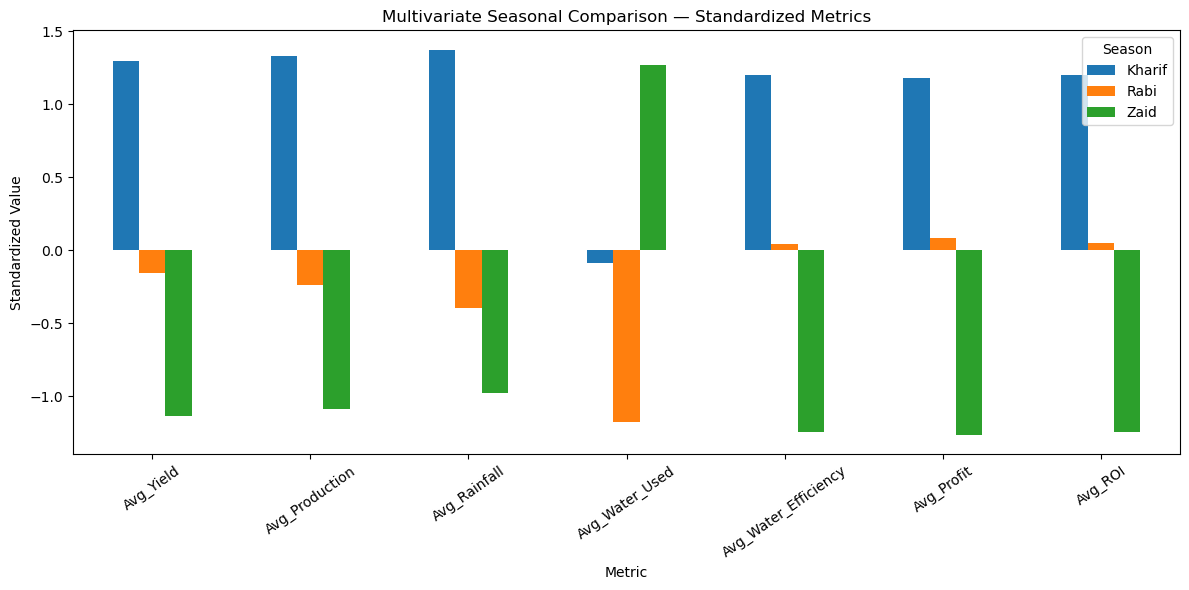

In [98]:
metrics = multivariate[
    [
        "Avg_Yield",
        "Avg_Production",
        "Avg_Rainfall",
        "Avg_Water_Used",
        "Avg_Water_Efficiency",
        "Avg_Profit",
        "Avg_ROI"
    ]
]

standardized = (metrics - metrics.mean()) / metrics.std(ddof=0)

standardized.T.plot(kind="bar", figsize=(12, 6))
plt.title("Multivariate Seasonal Comparison — Standardized Metrics")
plt.xlabel("Metric")
plt.ylabel("Standardized Value")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

Multivariate interpretation
The standardized comparison allows performance, resource use and environmental indicators to be examined together. This provides a broader seasonal view than examining yield or profit alone.

14. Correlation Analysis

In [99]:
numeric_cols = clean.select_dtypes(include="number").columns
correlation_matrix = clean[numeric_cols].corr()

yield_correlation = (
    correlation_matrix["Yield_Tonnes_Ha"]
    .drop("Yield_Tonnes_Ha")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Top variables associated with Yield:")
display(yield_correlation.head(10))

Top variables associated with Yield:


Water_Efficiency_t_per_1000m3    0.91
Production_Tonnes                0.88
ROI_pct                          0.52
Profit_INR                       0.49
Revenue_INR                      0.43
Water_Used_m3                    0.39
Market_Price_INR_Tonne          -0.38
Profit_Margin_pct                0.21
Nitrogen_kg_ha                   0.05
Phosphorus_kg_ha                 0.05
Name: Yield_Tonnes_Ha, dtype: float64

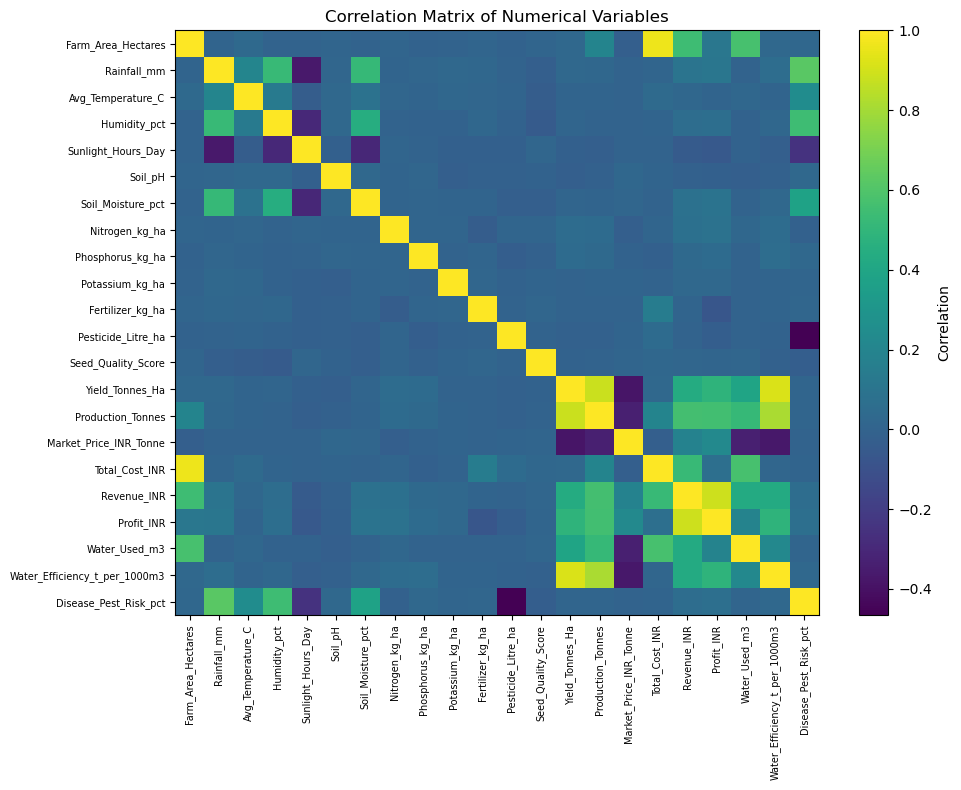

In [111]:
plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=7)
plt.yticks(range(len(corr.index)), corr.index, fontsize=7)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

Correlation interpretation
The strongest numerical association with Yield in this dataset is Water_Efficiency_t_per_1000m3 with a correlation of approximately 0.91.

15. Seasonal Comparisons

In [ ]:
This is the central analysis of the project.

In [101]:
season_summary = clean.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Production_Tonnes=("Production_Tonnes", "mean"),
    Avg_Revenue_INR=("Revenue_INR", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Avg_Rainfall_mm=("Rainfall_mm", "mean"),
    Avg_Temperature_C=("Avg_Temperature_C", "mean"),
    Avg_Water_Used_m3=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Disease_Risk_pct=("Disease_Pest_Risk_pct", "mean"),
    Avg_ROI_pct=("ROI_pct", "mean")
).reindex(season_order).round(2)

display(season_summary)

,Records,Avg_Yield_Tonnes_Ha,Avg_Production_Tonnes,Avg_Revenue_INR,Avg_Profit_INR,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Risk_pct,Avg_ROI_pct
Season,,,,,,,,,,,
Kharif,1779,5.63,46.31,"710,719.06","178,914.65",852.11,28.45,"6,102.20",5.89,54.47,35.45
Rabi,1627,5.04,41.49,"601,526.05","87,689.47",435.94,23.49,"5,846.99",5.19,40.48,17.60
Zaid,594,4.64,38.89,"519,171.90","-24,804.82",299.12,31.04,"6,419.89",4.41,38.22,-2.47


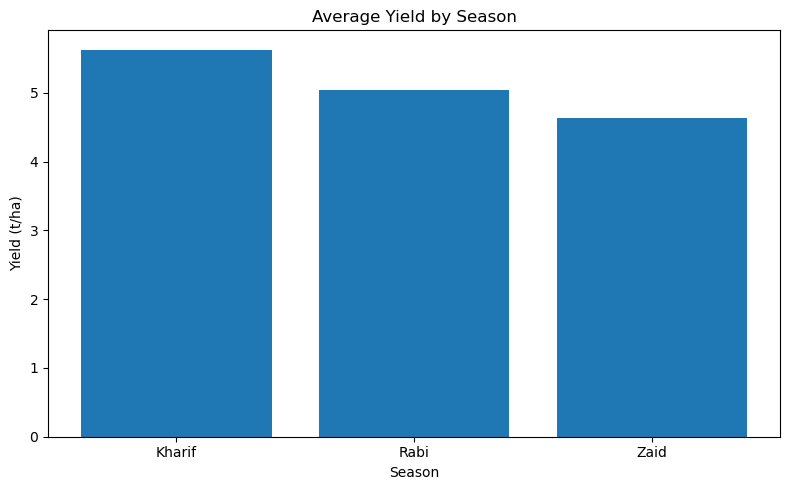

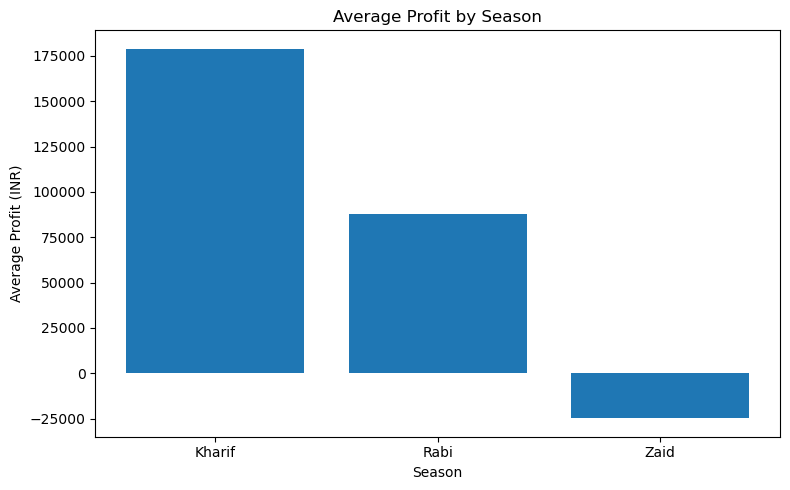

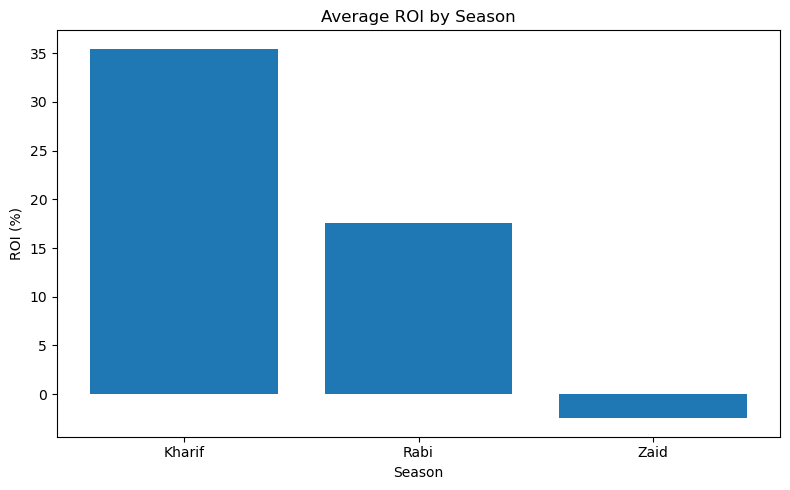

In [102]:
# Seasonal Yield comparison
plt.figure(figsize=(8, 5))
plt.bar(season_order, season_summary["Avg_Yield_Tonnes_Ha"])
plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Yield (t/ha)")
plt.tight_layout()
plt.show()

# Seasonal Profit comparison
plt.figure(figsize=(8, 5))
plt.bar(season_order, season_summary["Avg_Profit_INR"])
plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

# Seasonal ROI comparison
plt.figure(figsize=(8, 5))
plt.bar(season_order, season_summary["Avg_ROI_pct"])
plt.title("Average ROI by Season")
plt.xlabel("Season")
plt.ylabel("ROI (%)")
plt.tight_layout()
plt.show()

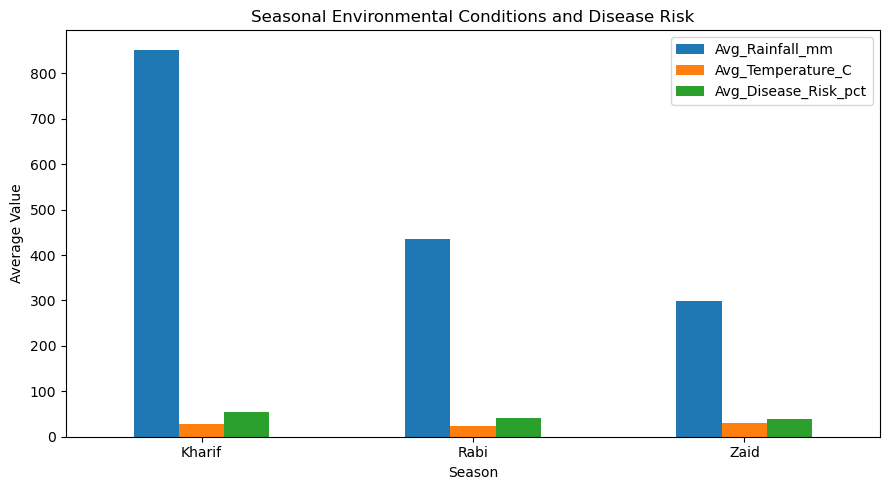

In [103]:
# Environmental comparison
environment = season_summary[
    [
        "Avg_Rainfall_mm",
        "Avg_Temperature_C",
        "Avg_Disease_Risk_pct"
    ]
]

environment.plot(kind="bar", figsize=(9, 5))
plt.title("Seasonal Environmental Conditions and Disease Risk")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

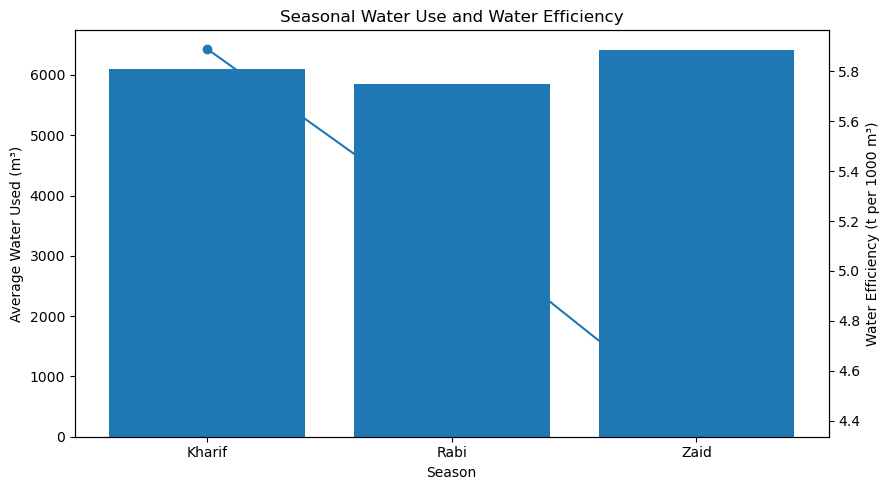

In [104]:
# Water use and efficiency
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.bar(
    season_order,
    season_summary["Avg_Water_Used_m3"]
)
ax1.set_xlabel("Season")
ax1.set_ylabel("Average Water Used (m³)")

ax2 = ax1.twinx()
ax2.plot(
    season_order,
    season_summary["Avg_Water_Efficiency"],
    marker="o"
)
ax2.set_ylabel("Water Efficiency (t per 1000 m³)")

plt.title("Seasonal Water Use and Water Efficiency")
plt.tight_layout()
plt.show()

Seasonal comparison findings

Kharif has the highest average yield.
Kharif has the highest average profit.
Zaid has the lowest average yield.
Zaid has the lowest average ROI.
Kharif has the highest water efficiency, while Zaid has the lowest.
Kharif has the highest average disease/pest risk.

These results show that agricultural performance varies by season and should be evaluated using several KPIs rather than yield alone.

16. Question-Driven Analyses

Five question-driven analyses are included below. Each question has code, a visualization/table, and an evidence-based interpretation.

In [ ]:
Question 1 — Which season has the strongest overall agricultural performance?
Decision: yield, production, profit and ROI.

In [105]:
question1 = season_summary[
    [
        "Avg_Yield_Tonnes_Ha",
        "Avg_Production_Tonnes",
        "Avg_Profit_INR",
        "Avg_ROI_pct"
    ]
]

display(question1)

print("Highest average yield:", question1["Avg_Yield_Tonnes_Ha"].idxmax())
print("Highest average production:", question1["Avg_Production_Tonnes"].idxmax())
print("Highest average profit:", question1["Avg_Profit_INR"].idxmax())
print("Highest average ROI:", question1["Avg_ROI_pct"].idxmax())

,Avg_Yield_Tonnes_Ha,Avg_Production_Tonnes,Avg_Profit_INR,Avg_ROI_pct
Season,,,,
Kharif,5.63,46.31,"178,914.65",35.45
Rabi,5.04,41.49,"87,689.47",17.60
Zaid,4.64,38.89,"-24,804.82",-2.47


Highest average yield: Kharif
Highest average production: Kharif
Highest average profit: Kharif
Highest average ROI: Kharif


Question 2 — Which season has the highest average profit, and what does this indicate about its economic performance?

In [122]:
# Calculate average profit by season

avg_profit = df.groupby("Season")["Profit_INR"].mean()

print("Average Profit by Season:")
print(avg_profit)

# Find the season with the highest average profit
highest_profit_season = avg_profit.idxmax()
highest_profit_value = avg_profit.max()

print("\nSeason with Highest Average Profit:", highest_profit_season)
print("Highest Average Profit:", round(highest_profit_value, 2))

Average Profit by Season:
Season
Kharif   178,914.65
Rabi      87,689.47
Zaid     -24,804.82
Name: Profit_INR, dtype: float64

Season with Highest Average Profit: Kharif
Highest Average Profit: 178914.65


In [123]:
Question 3 — Which crops perform best in each season?

Type:        str
String form: Zaid
Length:      4
Docstring:  
str(object='') -> str
str(bytes_or_buffer[, encoding[, errors]]) -> str

Create a new string object from the given object. If encoding or
errors is specified, then the object must expose a data buffer
that will be decoded using the given encoding and error handler.
Otherwise, returns the result of object.__str__() (if defined)
or repr(object).
encoding defaults to 'utf-8'.
errors defaults to 'strict'.

In [107]:
crop_season = clean.groupby(["Season", "Crop"]).agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Production=("Production_Tonnes", "mean"),
    Avg_Profit=("Profit_INR", "mean")
).round(2)

for season in season_order:
    print(f"\nTop 5 crops by average yield — {season}")
    display(
        crop_season.loc[season]
        .sort_values("Avg_Yield", ascending=False)
        .head(5)
    )


Top 5 crops by average yield — Kharif


,Avg_Yield,Avg_Production,Avg_Profit
Crop,,,
Sugarcane,53.46,446.07,"1,000,790.81"
Maize,2.97,23.35,"-39,332.67"
Rice,2.70,22.45,"-64,903.40"
Wheat,2.25,18.31,"-105,871.87"
Chilli,1.73,14.46,"954,380.42"



Top 5 crops by average yield — Rabi


,Avg_Yield,Avg_Production,Avg_Profit
Crop,,,
Sugarcane,43.28,365.26,"731,612.86"
Maize,2.60,21.59,"-89,133.40"
Rice,2.32,17.22,"-98,427.87"
Wheat,2.06,16.07,"-119,954.57"
Chilli,1.46,10.97,"638,572.50"



Top 5 crops by average yield — Zaid


,Avg_Yield,Avg_Production,Avg_Profit
Crop,,,
Sugarcane,38.42,329.56,"583,635.80"
Maize,2.29,17.94,"-194,049.17"
Rice,1.90,15.11,"-227,239.34"
Wheat,1.75,14.06,"-193,208.95"
Chilli,1.19,9.98,"448,659.09"


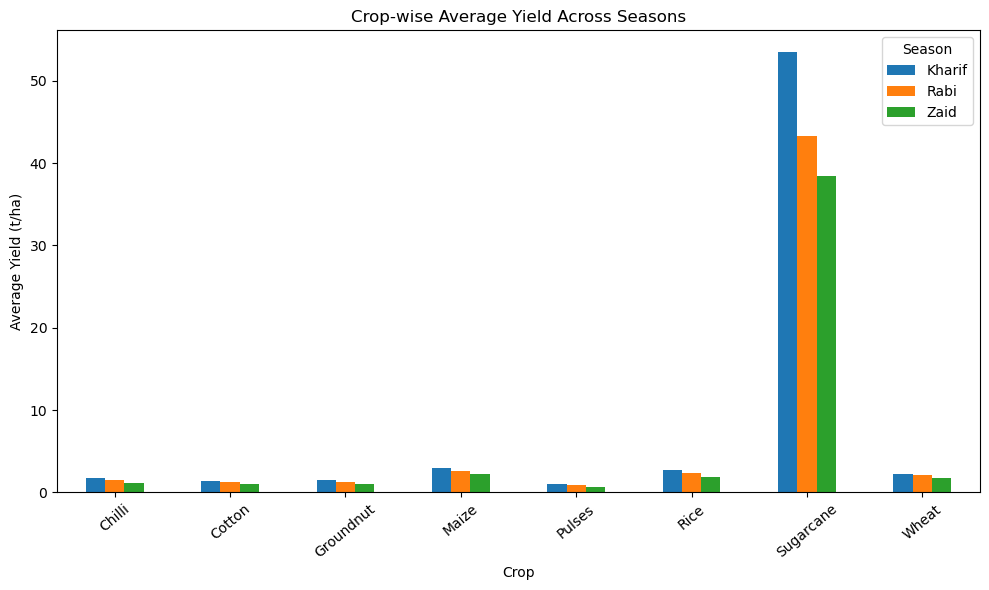

In [108]:
yield_pivot = (
    crop_season["Avg_Yield"]
    .unstack("Season")
    .reindex(columns=season_order)
)

yield_pivot.plot(kind="bar", figsize=(10, 6))
plt.title("Crop-wise Average Yield Across Seasons")
plt.xlabel("Crop")
plt.ylabel("Average Yield (t/ha)")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

,Avg_Water_Used_m3,Avg_Water_Efficiency
Season,,
Kharif,"6,102.20",5.89
Rabi,"5,846.99",5.19
Zaid,"6,419.89",4.41


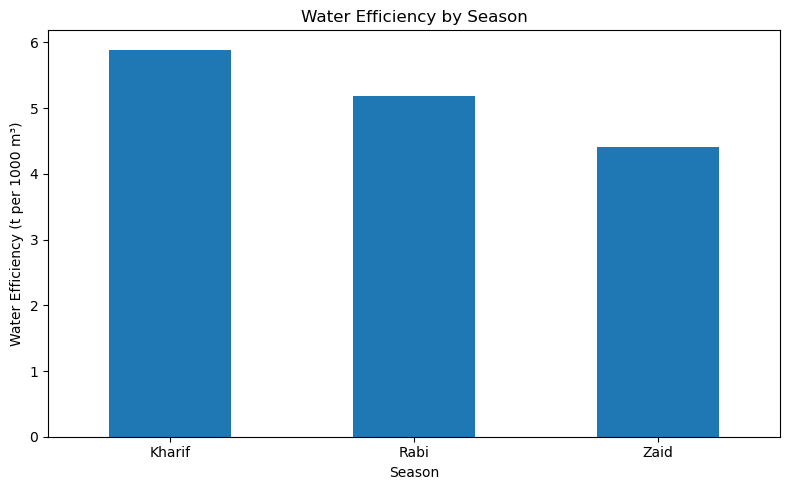

In [109]:
water_analysis = season_summary[
    ["Avg_Water_Used_m3", "Avg_Water_Efficiency"]
]

display(water_analysis)

water_analysis["Avg_Water_Efficiency"].plot(
    kind="bar",
    figsize=(8, 5)
)
plt.title("Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency (t per 1000 m³)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Avg_Production_Tonnes,Avg_Revenue_INR,Avg_Profit_INR,Avg_ROI_pct
Season,,,,
Kharif,46.31,"710,719.06","178,914.65",35.45
Rabi,41.49,"601,526.05","87,689.47",17.60
Zaid,38.89,"519,171.90","-24,804.82",-2.47


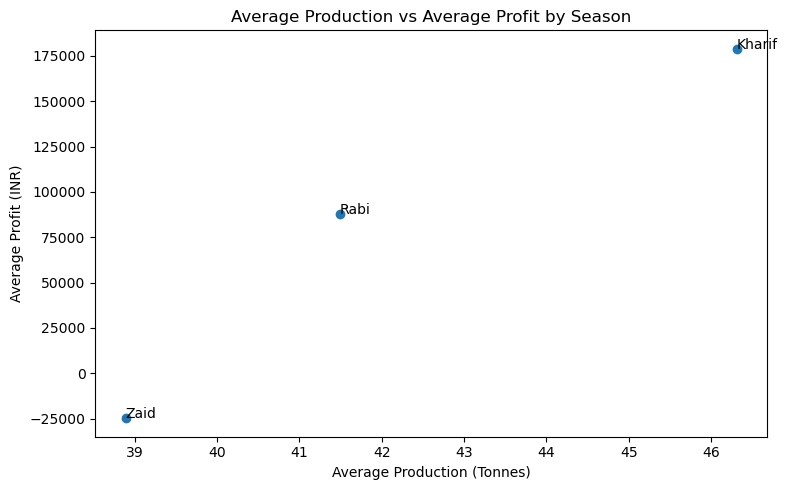

In [110]:
profitability_check = season_summary[
    [
        "Avg_Production_Tonnes",
        "Avg_Revenue_INR",
        "Avg_Profit_INR",
        "Avg_ROI_pct"
    ]
]

display(profitability_check)

plt.figure(figsize=(8, 5))
plt.scatter(
    profitability_check["Avg_Production_Tonnes"],
    profitability_check["Avg_Profit_INR"]
)

for season in profitability_check.index:
    plt.annotate(
        season,
        (
            profitability_check.loc[season, "Avg_Production_Tonnes"],
            profitability_check.loc[season, "Avg_Profit_INR"]
        )
    )

plt.title("Average Production vs Average Profit by Season")
plt.xlabel("Average Production (Tonnes)")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

Key Findings

Recommendations